# 12.1 一段聲音，怎麼存成一串數字？


先看一個振幅 0.5、每秒振動 440 次的合成單音。它不是人說的句子；希望用一串數字表示聲音隨時間的變化，並分清一個數字與一個完整週期。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

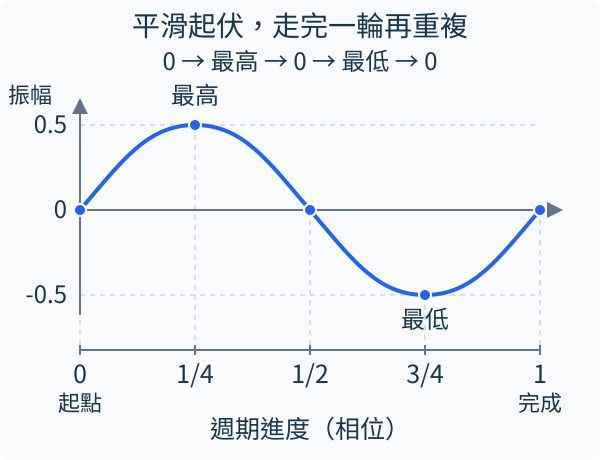

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/multimodal_wave_cycle.svg")))

聲音的波形在這裡是一維 tensor，每個位置是一個時間點的振幅。正負表示相對零點的方向，不是高低音標籤。圖中上升到 0.5、下降到 −0.5 再回到起點是一個週期；週期重複得越快，這種單音的頻率越高。


In [3]:
from tiny_perceptron.multimodal import tone

wave = tone(440.0)
print("樣本形狀", tuple(wave.shape))
print("前三個值", [round(v, 3) for v in wave[:3].tolist()])
print("最小最大", round(wave.min().item(), 2), round(wave.max().item(), 2))

樣本形狀 (1600,)
前三個值 [0.0, 0.086, 0.169]
最小最大 -0.5 0.5


`tone(440.0)` 預設每秒取 16000 個點、長 0.1 秒，產生 1600 個樣本。前三個數約為 `[0.0,0.086,0.169]`，最小與最大約 −0.5、0.5。440 Hz 表示每秒 440 個週期，不能把第 440 個樣本當作 440 Hz 的意思。

振幅與頻率是不同變化。把振幅倍增，數字起伏變大而週期不變；把頻率倍增，同樣時間內起伏更密。真實聲音通常混合許多頻率，波形不像本圖這麼規則，因此不能只找一個最高點就辨認說了什麼。

批次處理可增加軸，將兩段等長聲音排成 `[2,1600]`。若錄音長度不同，需要另外約定補齊與有效長度，補出的零不能算作真人沉默的證據。練習把呼叫改成 `wave = tone(440.0, seconds=0.2)`，其中 `seconds` 指時長；預期樣本數 3200，頻率仍是 440 Hz，不表示音高變成兩倍。

<details>
<summary>回顧與查證</summary>

可回顧：[W.3的一維tensor](https://birdhackor.github.io/tiny-perceptron-vlm/first-steps.html#W.3)。

</details>
